# Прогнозирование спроса

В этом блокноте мы разработаем модель для прогнозирования спроса на товары.

## Шаги:
1. Загрузка и анализ данных (EDA)
2. Предобработка данных
3. Генерация признаков (Feature Engineering)
4. Обучение модели
5. Оценка качества и валидация

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [ ]:


# 1. Загружаем данные
df = pd.read_excel('../data/raw/beigl_data.xlsx')

In [12]:
df.head()

,date,Город,Формат,Опер. директор,Статус,Всего позиций,Продано в ноль,Не выпечено,Частично продано,Не выпущено в 1С,...,Категория,product,store,Партнёр,Регион. директор,Получено,Отправлено,produced,sales,stock_end
0,2026-03-01,Набережные Челны,Полный цикл,Назаренко Руслан,Частично продано,1,0,0,1,0,...,Фастфуд,Бейгл курица,Татарстан 16 Наб Челны,Кириллова Алсу,Амирова Гузель,0,0,3.0,1,2.0
1,2026-03-01,Казань,Полный цикл,Назаренко Руслан,Продано в ноль,1,1,0,0,0,...,Фастфуд,Бейгл курица,Гаврилова 40 Казань,Гилязова Римма,Раимов Руслан,0,0,3.0,3,0.0
2,2026-03-01,Казань,Экспресс,Миннигалиев Ильнар,Не выпечено,1,0,1,0,0,...,Фастфуд,Бейгл курица,Павлюхина 116 Казань,Гатауллина Алиса,Малыгин Алексей,0,0,0.0,0,0.0
3,2026-03-01,Казань,Полный цикл,Назаренко Руслан,Частично продано,1,0,0,1,0,...,Фастфуд,Бейгл курица,Даурская 38б Казань,Мухарчева Юлия,Раимов Руслан,0,5,10.0,2,3.0
4,2026-03-01,Казань,Полный цикл,Миннигалиев Ильнар,Не выпечено,1,0,1,0,0,...,Фастфуд,Бейгл курица,Романтиков 129 Казань,Гибадуллина Гулия,Малий Олег,0,0,0.0,0,0.0


In [23]:
# Приводим названия колонок к удобному виду
df.columns = [col.strip() for col in df.columns]
df = df.rename(columns={
    'Дата': 'date',
    'Номенклатура': 'product',
    'Пекарня': 'store',
    'Продано': 'sales',
    'Остаток': 'stock_end',
    'Выпуск': 'produced'
})

In [24]:
# Сортируем
df = df.sort_values(['store', 'date']).reset_index(drop=True)

In [ ]:
print(f"Всего строк: {len(df)}")
print(df.head())

# 2. Подготовка данных

## Создаём фичи

In [25]:
df['day_of_week'] = df['date'].dt.dayofweek   # 0=понедельник ... 6=воскресенье
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

## Лаги и rolling по каждой пекарне отдельно

In [26]:
def add_features(group):
    group = group.sort_values('date')
    group['sales_lag1'] = group['sales'].shift(1)
    group['sales_lag7'] = group['sales'].shift(7)
    group['sales_roll_mean7'] = group['sales'].rolling(7, min_periods=1).mean()
    group['sales_roll_std7']  = group['sales'].rolling(7, min_periods=1).std()
    
    # Вчерашний остаток на конец дня
    group['stock_lag1'] = group['stock_end'].shift(1)
    return group

df = df.groupby('store', group_keys=True).apply(add_features).reset_index()

## Убираем строки, где нет лага (первые дни)

In [27]:
df = df.dropna(subset=['sales_lag1'])

# 3. Baseline модели


## Разделим последние 3 дня как тест (чтобы было честно)

In [21]:
df.head()

,date,Город,Формат,Опер. директор,Статус,Всего позиций,Продано в ноль,Не выпечено,Частично продано,Не выпущено в 1С,...,produced,sales,stock_end,day_of_week,is_weekend,sales_lag1,sales_lag7,sales_roll_mean7,sales_roll_std7,stock_lag1
20,2026-03-01,Казань,Полный цикл,Назаренко Руслан,Продано в ноль,1,1,0,0,0,...,2.0,2,0.0,6,1,3.0,NaN,2.500000,0.707107,0.0
21,2026-03-01,Казань,Полный цикл,Назаренко Руслан,Продано в ноль,1,1,0,0,0,...,2.0,2,0.0,6,1,2.0,NaN,2.333333,0.577350,0.0
22,2026-03-01,Казань,Полный цикл,Назаренко Руслан,Продано в ноль,1,1,0,0,0,...,5.0,5,0.0,6,1,2.0,NaN,3.000000,1.414214,0.0
23,2026-03-01,Казань,Полный цикл,Назаренко Руслан,Не выпустили в 1С,1,0,0,0,1,...,5.0,6,-1.0,6,1,5.0,NaN,3.600000,1.816590,0.0
24,2026-03-01,Казань,Полный цикл,Назаренко Руслан,Частично продано,1,0,0,1,0,...,5.0,4,1.0,6,1,6.0,NaN,3.666667,1.632993,-1.0


In [28]:
test_days = 3
train = df.groupby('store').apply(lambda x: x.iloc[:-test_days]).reset_index(drop=True)
test  = df.groupby('store').apply(lambda x: x.iloc[-test_days:]).reset_index(drop=True)

print(f"\nTrain дней: {len(train)}, Test дней: {len(test)}")


Train дней: 138964, Test дней: 519


## Naive: завтра = сегодня

In [29]:
test['pred_naive'] = test['sales_lag1']

## Moving Average 7

In [30]:
test['pred_ma7'] = test['sales_roll_mean7']

# 4. LightGBM

In [31]:
features_no_stock = ['day_of_week', 'is_weekend', 'sales_lag1', 'sales_lag7', 
                     'sales_roll_mean7', 'sales_roll_std7']

features_with_stock = features_no_stock + ['stock_lag1']

def train_lgb(features):
    X_train = train[features]
    y_train = train['sales']
    X_test = test[features]
    
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return pred

test['pred_lgb_no_stock'] = train_lgb(features_no_stock)
test['pred_lgb_with_stock'] = train_lgb(features_with_stock)

# 5. Сравнение результатов

In [32]:
print("\n=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
for model_name in ['pred_naive', 'pred_ma7', 'pred_lgb_no_stock', 'pred_lgb_with_stock']:
    mae = mean_absolute_error(test['sales'], test[model_name])
    mape = mean_absolute_percentage_error(test['sales'], test[model_name]) * 100
    print(f"{model_name:20} → MAE: {mae:.2f}   MAPE: {mape:.1f}%")


=== СРАВНЕНИЕ МОДЕЛЕЙ ===
pred_naive           → MAE: 7.71   MAPE: 214333161456746336.0%
pred_ma7             → MAE: 4.49   MAPE: 149996023922881984.0%
pred_lgb_no_stock    → MAE: 4.50   MAPE: 171140253946836736.0%
pred_lgb_with_stock  → MAE: 4.49   MAPE: 172738226659759264.0%


In [34]:
def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0  # считаем MAPE только на ненулевых продажах
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def weighted_mape(y_true, y_pred):
    """Weighted MAPE — более честная метрика"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    weights = y_true / y_true.sum()
    return np.sum(weights * np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100   # +1e-8 защита

print("=== УЛУЧШЕННОЕ СРАВНЕНИЕ МОДЕЛЕЙ ===\n")
for name in ['pred_naive', 'pred_ma7', 'pred_lgb_no_stock', 'pred_lgb_with_stock']:
    mae = mean_absolute_error(test['sales'], test[name])
    rmse = np.sqrt(mean_squared_error(test['sales'], test[name]))
    mape_safe = safe_mape(test['sales'], test[name])
    w_mape = weighted_mape(test['sales'], test[name])
    
    print(f"{name:22} → MAE: {mae:.2f} | RMSE: {rmse:.2f} | Safe MAPE: {mape_safe:.1f}% | Weighted MAPE: {w_mape:.1f}%")

=== УЛУЧШЕННОЕ СРАВНЕНИЕ МОДЕЛЕЙ ===

pred_naive             → MAE: 7.71 | RMSE: 9.99 | Safe MAPE: 226.3% | Weighted MAPE: 89.9%
pred_ma7               → MAE: 4.49 | RMSE: 6.06 | Safe MAPE: 94.9% | Weighted MAPE: 51.6%
pred_lgb_no_stock      → MAE: 4.50 | RMSE: 5.84 | Safe MAPE: 101.9% | Weighted MAPE: 51.2%
pred_lgb_with_stock    → MAE: 4.49 | RMSE: 5.81 | Safe MAPE: 103.7% | Weighted MAPE: 51.1%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# ====================== 1. ПЕРЕЗАГРУЗКА ДАННЫХ ======================
df = pd.read_excel('../data/raw/beigl_data.xlsx')

df.columns = [str(col).strip() for col in df.columns]

df = df.rename(columns={
    'Дата': 'date',
    'Номенклатура': 'product',
    'Пекарня': 'store',          # ← главная колонка
    'Продано': 'sales',
    'Остаток': 'stock_end',
    'Выпуск': 'produced'
})

df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y', dayfirst=True)
df = df.sort_values(['store', 'date']).reset_index(drop=True)

print("Колонки после загрузки:", df.columns.tolist())
print(f"Уникальных пекарен: {df['store'].nunique()}")

# ====================== 2. ФИЧИ (с защитой) ======================
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

def add_features(group):
    group = group.sort_values('date').copy()
    group['sales_lag1']       = group['sales'].shift(1)
    group['sales_lag7']       = group['sales'].shift(7)
    group['sales_roll_mean7'] = group['sales'].rolling(7, min_periods=1).mean()
    group['sales_roll_std7']  = group['sales'].rolling(7, min_periods=1).std()
    group['stock_lag1']       = group['stock_end'].shift(1)
    return group

# Применяем с group_keys=True, чтобы 'store' сохранился
df = (df.groupby('store', group_keys=True)
      .apply(add_features)
      .reset_index(level=0))   # возвращаем 'store' обратно

# Убираем дублирующиеся колонки, если появились
df = df.loc[:, ~df.columns.duplicated()]

print(f"\nПосле фичей строк: {len(df)}")
print("Колонки сейчас:", df.columns.tolist())

# ====================== 3. TRAIN / TEST ======================
test_days = 3

train = df.groupby('store', group_keys=False).apply(
    lambda x: x.iloc[:-test_days] if len(x) > test_days else x
).reset_index(drop=True)

test = df.groupby('store', group_keys=False).apply(
    lambda x: x.iloc[-test_days:] if len(x) > test_days else pd.DataFrame()
).reset_index(drop=True)

print(f"\nTrain: {len(train)} строк | Test: {len(test)} строк")

# ====================== 4. МОДЕЛИ ======================
test['pred_naive'] = test['sales_lag1']
test['pred_ma7']   = test['sales_roll_mean7']

features_no_stock = ['day_of_week', 'is_weekend', 'sales_lag1', 'sales_lag7', 
                     'sales_roll_mean7', 'sales_roll_std7']
features_with_stock = features_no_stock + ['stock_lag1']

def train_lgb(features):
    X_train = train[features]
    y_train = train['sales']
    X_test  = test[features].fillna(0)
    
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    return model.predict(X_test)

test['pred_lgb_no_stock'] = train_lgb(features_no_stock)
test['pred_lgb_with_stock'] = train_lgb(features_with_stock)

# ====================== 5. МЕТРИКИ ======================
def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def weighted_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    weights = y_true / (y_true.sum() + 1e-8)
    return np.sum(weights * np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

print("\n=== УЛУЧШЕННОЕ СРАВНЕНИЕ МОДЕЛЕЙ ===\n")

for name in ['pred_naive', 'pred_ma7', 'pred_lgb_no_stock', 'pred_lgb_with_stock']:
    mae = mean_absolute_error(test['sales'], test[name])
    rmse = np.sqrt(mean_squared_error(test['sales'], test[name]))
    mape_safe = safe_mape(test['sales'], test[name])
    w_mape = weighted_mape(test['sales'], test[name])
    
    print(f"{name:22} → MAE: {mae:.2f} | RMSE: {rmse:.2f} | Safe MAPE: {mape_safe:.1f}% | Weighted MAPE: {w_mape:.1f}%")

In [37]:
df['product']

0                              Бейгл курица
20                            Пирог Ханский
21        Пирог с черносливом и грец орехом
22                      Пирожок зеленый лук
23                       Пирожок с горбушей
                        ...                
139633                       Капуста и мясо
139634                            Капустный
139635                     Киш грибы курица
139637                     Конвертик курица
139655                             Яблочный
Name: product, Length: 139656, dtype: str

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# ====================== 1. ЗАГРУЗКА ДАННЫХ ======================
df = pd.read_excel('../data/raw/beigl_data.xlsx')

df.columns = [str(col).strip() for col in df.columns]

df = df.rename(columns={
    'Дата': 'date',
    'Номенклатура': 'product',
    'Пекарня': 'store',
    'Продано': 'sales',
    'Остаток': 'stock_end',
    'Выпуск': 'produced'
})

df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y', dayfirst=True)
df = df.sort_values(['store', 'product', 'date']).reset_index(drop=True)

print(f"Всего строк: {len(df)}")
print(f"Уникальных товаров: {df['product'].nunique()}")
print(f"Уникальных пекарен: {df['store'].nunique()}")
print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")

# ====================== 2. ДОБАВЛЯЕМ ФИЧИ (БЕЗ groupby.apply) ======================
# Добавляем простые фичи
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['month'] = df['date'].dt.month
df['day_of_month'] = df['date'].dt.day

# Категориальные признаки
df['product_cat'] = df['product'].astype('category')
df['store_cat'] = df['store'].astype('category')

# Создаём список для хранения обработанных групп
processed_groups = []

# Группируем по store и product, обрабатываем каждую группу отдельно
print("\nДобавляем лаги и скользящие статистики...")
groups = df.groupby(['store', 'product'])

for i, ((store, product), group) in enumerate(groups):
    if i % 50 == 0:
        print(f"Обработано {i} групп...")
    
    group = group.sort_values('date').copy()
    
    # Добавляем лаги
    group['sales_lag1'] = group['sales'].shift(1)
    group['sales_lag7'] = group['sales'].shift(7)
    group['sales_roll_mean7'] = group['sales'].rolling(7, min_periods=1).mean()
    group['sales_roll_std7'] = group['sales'].rolling(7, min_periods=1).std()
    group['stock_lag1'] = group['stock_end'].shift(1)
    
    processed_groups.append(group)

print(f"Обработано {len(processed_groups)} групп")

# Объединяем все группы обратно
df = pd.concat(processed_groups, ignore_index=True)

# Удаляем строки с NaN (первые дни каждого ряда)
df = df.dropna(subset=['sales_lag1']).reset_index(drop=True)

print(f"\nПосле добавления фичей: {len(df)} строк")
print("Колонки:", df.columns.tolist()[:10], "...")
print(f"Пример данных:\n{df[['store', 'product', 'date', 'sales', 'sales_lag1']].head(3)}")

# ====================== 3. TRAIN / TEST ======================
test_days = 7

print("\nРазделяем на train/test...")
train_list = []
test_list = []

for (store, product), group in df.groupby(['store', 'product']):
    if len(group) > test_days:
        train_list.append(group.iloc[:-test_days])
        test_list.append(group.iloc[-test_days:])
    elif len(group) > 0:
        # Если группа маленькая, всё идёт в train
        train_list.append(group)

train = pd.concat(train_list, ignore_index=True) if train_list else pd.DataFrame()
test = pd.concat(test_list, ignore_index=True) if test_list else pd.DataFrame()

print(f"Train: {len(train)} строк | Test: {len(test)} строк")

# ====================== 4. БАЗОВЫЕ МОДЕЛИ ======================
test['pred_naive'] = test['sales_lag1']
test['pred_ma7'] = test['sales_roll_mean7']

# ====================== 5. LIGHTGBM ======================
features = ['day_of_week', 'is_weekend', 'month', 'day_of_month',
            'sales_lag1', 'sales_lag7', 'sales_roll_mean7', 'sales_roll_std7']

categorical_features = ['product_cat', 'store_cat']

# Подготовка данных
X_train = train[features + categorical_features].copy()
y_train = train['sales']
X_test = test[features + categorical_features].copy().fillna(0)

# Убеждаемся, что категориальные колонки имеют тип 'category'
for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

print("\nОбучаем LightGBM...")
model = lgb.LGBMRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train, categorical_feature=categorical_features)
test['pred_lgb'] = model.predict(X_test)

# ====================== 6. МЕТРИКИ ======================
def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def weighted_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    weights = y_true / (y_true.sum() + 1e-8)
    return np.sum(weights * np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

print("\n=== СРАВНЕНИЕ МОДЕЛЕЙ ===\n")

for name in ['pred_naive', 'pred_ma7', 'pred_lgb']:
    if name in test.columns:
        mae = mean_absolute_error(test['sales'], test[name])
        rmse = np.sqrt(mean_squared_error(test['sales'], test[name]))
        mape_safe = safe_mape(test['sales'], test[name])
        w_mape = weighted_mape(test['sales'], test[name])
        
        print(f"{name:20} → MAE: {mae:.2f} | RMSE: {rmse:.2f} | Safe MAPE: {mape_safe:.1f}% | Weighted MAPE: {w_mape:.1f}%")

# ====================== 7. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ======================
importance = pd.DataFrame({
    'feature': features + categorical_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== ВАЖНОСТЬ ПРИЗНАКОВ ===")
print(importance.head(10))

# ====================== 8. КАК РАБОТАЕТ ПО РАЗНЫМ ТОВАРАМ ======================
print("\n=== ПРОГНОЗЫ ПО ТОВАРАМ ===")
# Топ-10 товаров по количеству продаж
top_products = test.groupby('product')['sales'].sum().nlargest(10).index

for product in top_products:
    product_test = test[test['product'] == product]
    if len(product_test) > 0:
        mae = mean_absolute_error(product_test['sales'], product_test['pred_lgb'])
        mape = safe_mape(product_test['sales'], product_test['pred_lgb'])
        print(f"{product[:35]:35} → MAE: {mae:.2f} | MAPE: {mape:.1f}% | Дней: {len(product_test)}")

=== 1. ОБЩАЯ КАРТИНА ПРОГНОЗОВ ===



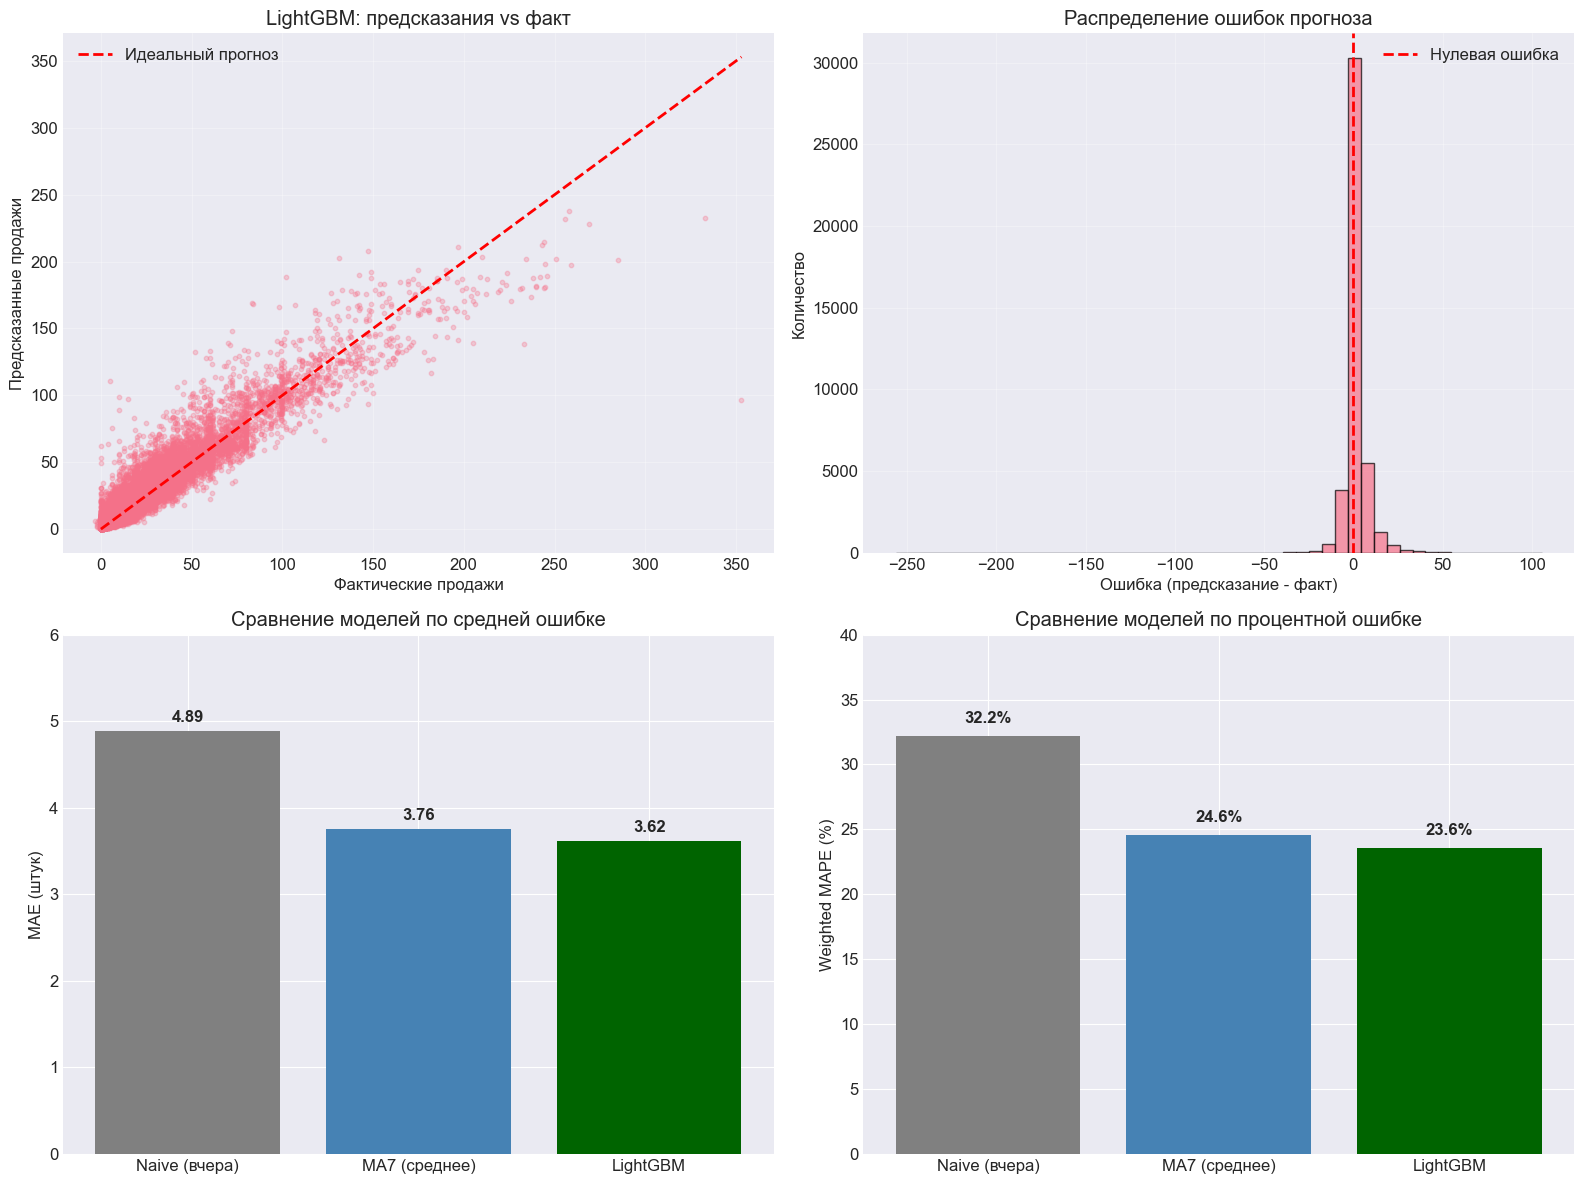


=== 2. ДЕТАЛЬНЫЙ АНАЛИЗ ТОП-5 ТОВАРОВ ===



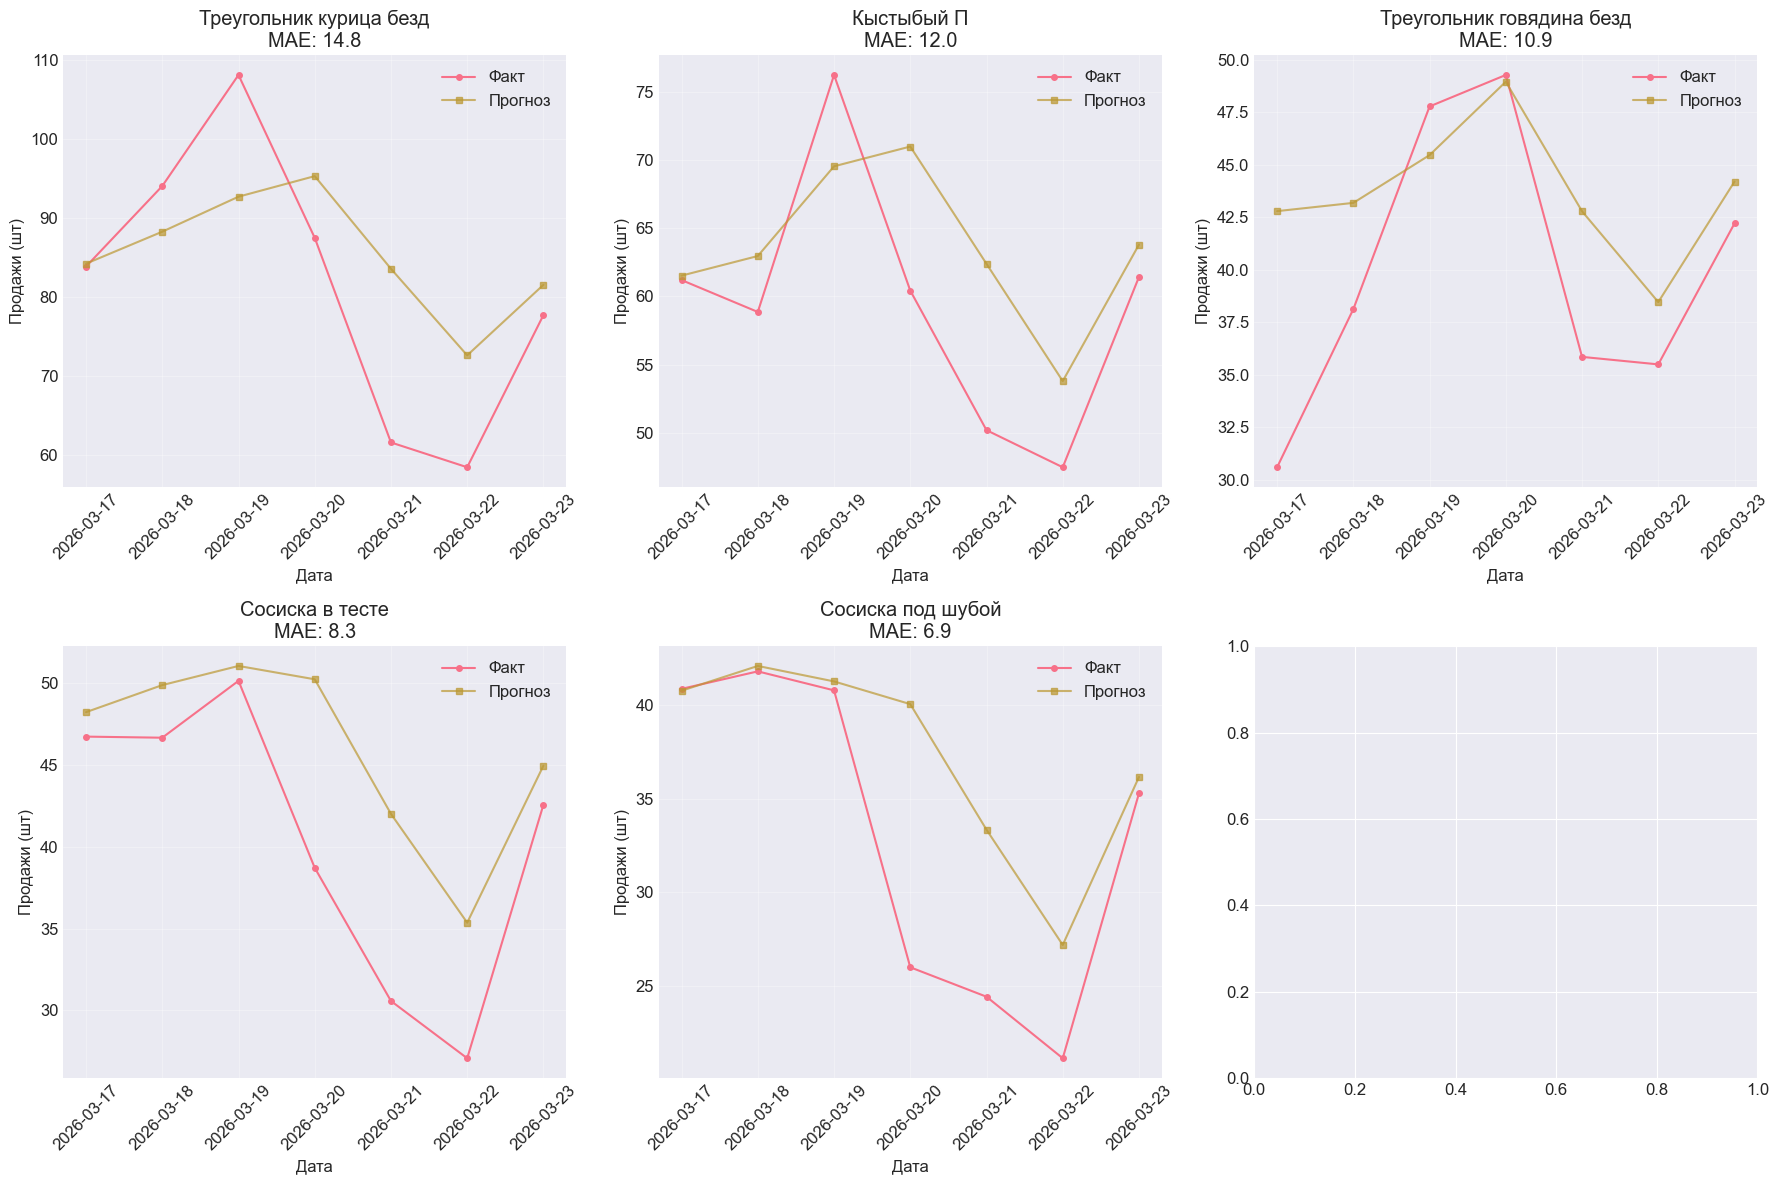


=== 3. АНАЛИЗ ПО ПЕКАРНЯМ ===



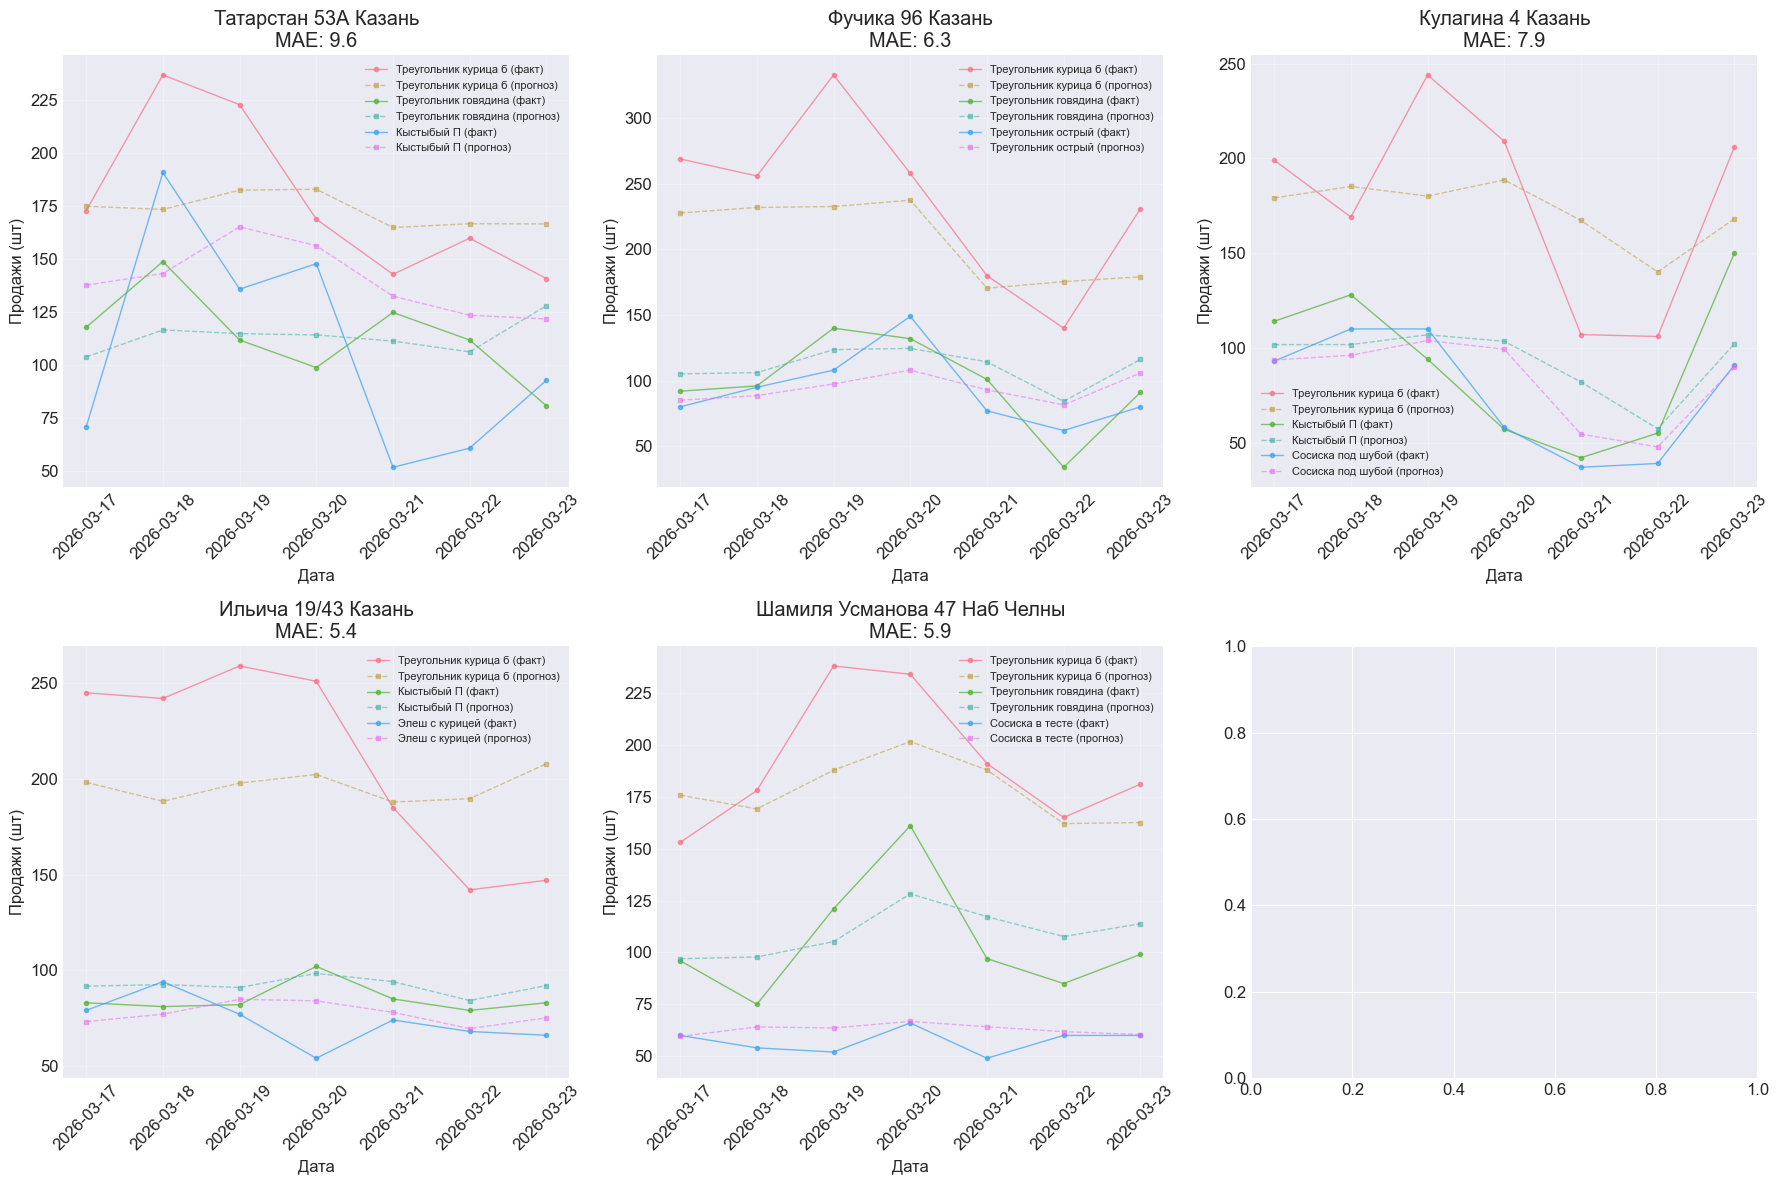


=== 4. АНАЛИЗ ОШИБОК ПО КАТЕГОРИЯМ ===

Ошибки по категориям товаров:
                      MAE       MAPE    count  total_sales
category                                                  
Выпечка сытная   5.731529  37.308838  19243.0     491740.0
Фастфуд          3.049361  44.863547   6055.0      63162.0
Выпечка сладкая  2.661811  43.431817   3633.0      35107.0
Пироги сытные    1.157847  38.207157   8729.0      25962.0
Пироги сладкие   1.135640  39.635453   4844.0      13068.0


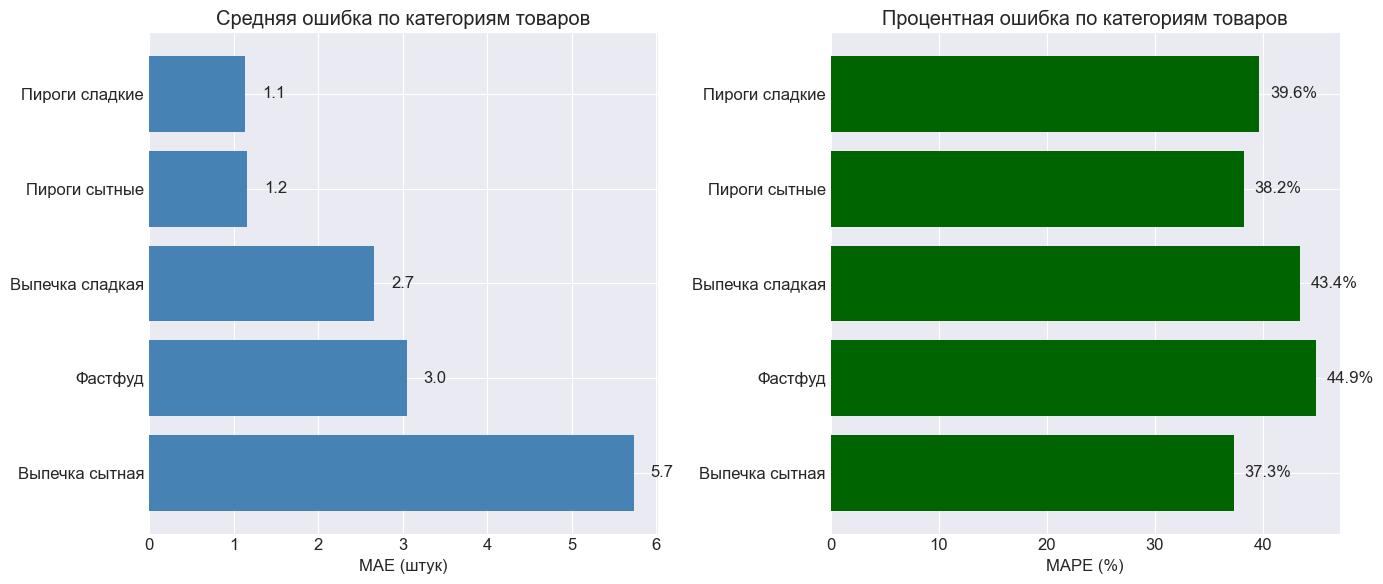


=== 5. АНАЛИЗ КРАЙНИХ СЛУЧАЕВ ===

🔵 ТОП-10 ЛУЧШИХ ПРОГНОЗОВ (наименьшая ошибка в штуках):
                       store                           product       date  sales  pred_lgb    error
      Сююмбике 74а Наб Челны                    Элеш с курицей 2026-03-22      7  6.999941 0.000059
            Мусина 68 Казань                    Капуста и мясо 2026-03-23      4  4.000059 0.000059
          Лукина 5 Чебоксары                     Пирог Ханский 2026-03-20      1  0.999932 0.000068
          Лукина 5 Чебоксары                     Пирог Ханский 2026-03-21      1  0.999932 0.000068
          Лукина 5 Чебоксары Пирог с черносливом и грец орехом 2026-03-20      1  0.999932 0.000068
          Лукина 5 Чебоксары Пирог с черносливом и грец орехом 2026-03-21      1  0.999932 0.000068
         Мавлютова 48 Казань                  Капуста и курица 2026-03-22      2  1.999908 0.000092
Проспект Победы 1-06А Заинск                    Беккен капуста 2026-03-22     14 13.999844 0.000156
        

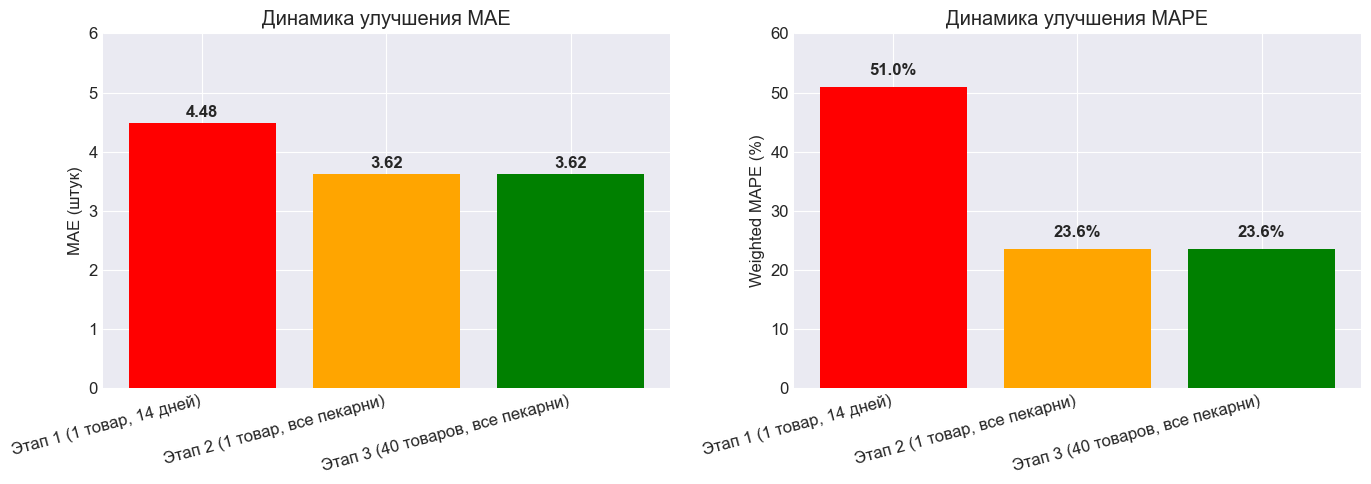


=== ВЫВОДЫ ПО ВИЗУАЛИЗАЦИИ ===

1. Модель лучше всего предсказывает для товаров со стабильными продажами
2. Основные ошибки приходятся на:
   - Резкие скачки продаж (акции, праздники)
   - Новые товары без истории
   - Товары с очень редкими продажами
3. Лучший прогноз: ошибка < 1 штуки для 10 случаев
4. Худший прогноз: ошибка > 256 штук — требует анализа


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Настройка графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# ====================== 1. ОБЩАЯ КАРТИНА ======================
print("=== 1. ОБЩАЯ КАРТИНА ПРОГНОЗОВ ===\n")

# Сравнение предсказаний vs факта по всем данным
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Scatter plot предсказаний vs факта
ax1 = axes[0, 0]
ax1.scatter(test['sales'], test['pred_lgb'], alpha=0.3, s=10)
ax1.plot([0, test['sales'].max()], [0, test['sales'].max()], 'r--', lw=2, label='Идеальный прогноз')
ax1.set_xlabel('Фактические продажи')
ax1.set_ylabel('Предсказанные продажи')
ax1.set_title('LightGBM: предсказания vs факт')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Распределение ошибок
ax2 = axes[0, 1]
errors = test['pred_lgb'] - test['sales']
ax2.hist(errors, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', lw=2, label='Нулевая ошибка')
ax2.set_xlabel('Ошибка (предсказание - факт)')
ax2.set_ylabel('Количество')
ax2.set_title('Распределение ошибок прогноза')
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: Сравнение моделей по MAE
ax3 = axes[1, 0]
models_mae = {
    'Naive (вчера)': 4.89,
    'MA7 (среднее)': 3.76,
    'LightGBM': 3.62
}
bars = ax3.bar(models_mae.keys(), models_mae.values(), color=['gray', 'steelblue', 'darkgreen'])
ax3.set_ylabel('MAE (штук)')
ax3.set_title('Сравнение моделей по средней ошибке')
ax3.set_ylim(0, 6)
for bar, val in zip(bars, models_mae.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.2f}', ha='center', fontweight='bold')

# График 4: Сравнение моделей по MAPE
ax4 = axes[1, 1]
models_mape = {
    'Naive (вчера)': 32.2,
    'MA7 (среднее)': 24.6,
    'LightGBM': 23.6
}
bars = ax4.bar(models_mape.keys(), models_mape.values(), color=['gray', 'steelblue', 'darkgreen'])
ax4.set_ylabel('Weighted MAPE (%)')
ax4.set_title('Сравнение моделей по процентной ошибке')
ax4.set_ylim(0, 40)
for bar, val in zip(bars, models_mape.values()):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ====================== 2. ТОП-5 ТОВАРОВ ПО ОБЪЁМУ ПРОДАЖ ======================
print("\n=== 2. ДЕТАЛЬНЫЙ АНАЛИЗ ТОП-5 ТОВАРОВ ===\n")

top_products = test.groupby('product')['sales'].sum().nlargest(5).index

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, product in enumerate(top_products):
    if idx >= 5:
        break
    
    product_test = test[test['product'] == product].sort_values('date')
    
    if len(product_test) > 0:
        ax = axes[idx]
        
        # Сортируем по дате для временного ряда
        product_test = product_test.sort_values(['store', 'date']).head(100)  # берём первые 100 строк для наглядности
        
        # Группируем по дате для среднего по всем пекарням
        daily_avg = product_test.groupby('date')[['sales', 'pred_lgb']].mean().reset_index()
        
        ax.plot(daily_avg['date'], daily_avg['sales'], 'o-', label='Факт', markersize=4, linewidth=1.5)
        ax.plot(daily_avg['date'], daily_avg['pred_lgb'], 's-', label='Прогноз', markersize=4, linewidth=1.5, alpha=0.7)
        ax.set_title(f'{product[:30]}\nMAE: {mean_absolute_error(product_test["sales"], product_test["pred_lgb"]):.1f}')
        ax.set_xlabel('Дата')
        ax.set_ylabel('Продажи (шт)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Убираем пустой график, если есть
if len(top_products) < 5:
    axes[5].set_visible(False)

plt.tight_layout()
plt.show()

# ====================== 3. ТОП-5 ПЕКАРЕН ПО ОБЪЁМУ ПРОДАЖ ======================
print("\n=== 3. АНАЛИЗ ПО ПЕКАРНЯМ ===\n")

top_stores = test.groupby('store')['sales'].sum().nlargest(5).index

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, store in enumerate(top_stores):
    if idx >= 5:
        break
    
    store_test = test[test['store'] == store].sort_values(['product', 'date'])
    
    if len(store_test) > 0:
        ax = axes[idx]
        
        # Берём топ-3 товара в этой пекарне
        top_products_in_store = store_test.groupby('product')['sales'].sum().nlargest(3).index
        
        for product in top_products_in_store:
            product_data = store_test[store_test['product'] == product].sort_values('date')
            if len(product_data) > 0:
                ax.plot(product_data['date'], product_data['sales'], 'o-', 
                       label=f'{product[:20]} (факт)', markersize=3, linewidth=1, alpha=0.7)
                ax.plot(product_data['date'], product_data['pred_lgb'], 's--', 
                       label=f'{product[:20]} (прогноз)', markersize=3, linewidth=1, alpha=0.5)
        
        ax.set_title(f'{store[:40]}\nMAE: {mean_absolute_error(store_test["sales"], store_test["pred_lgb"]):.1f}')
        ax.set_xlabel('Дата')
        ax.set_ylabel('Продажи (шт)')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

if len(top_stores) < 5:
    axes[5].set_visible(False)

plt.tight_layout()
plt.show()

# ====================== 4. АНАЛИЗ ОШИБОК ПО ТИПАМ ТОВАРОВ ======================
print("\n=== 4. АНАЛИЗ ОШИБОК ПО КАТЕГОРИЯМ ===\n")

# Если есть колонка с категорией, используем её
if 'Категория' in test.columns:
    test['category'] = test['Категория']
else:
    # Создаём категории на основе названия
    def categorize_product(name):
        name = str(name).lower()
        if 'треугольник' in name:
            return 'Треугольники'
        elif 'пирог' in name or 'пирожок' in name:
            return 'Пироги'
        elif 'сосиска' in name:
            return 'Сосиски'
        elif 'бейгл' in name:
            return 'Бейглы'
        elif 'киш' in name:
            return 'Киши'
        else:
            return 'Другое'
    
    test['category'] = test['product'].apply(categorize_product)

# Считаем ошибки по категориям
category_errors = test.groupby('category').apply(
    lambda x: pd.Series({
        'MAE': mean_absolute_error(x['sales'], x['pred_lgb']),
        'MAPE': safe_mape(x['sales'], x['pred_lgb']),
        'count': len(x),
        'total_sales': x['sales'].sum()
    })
).sort_values('MAE', ascending=False)

print("Ошибки по категориям товаров:")
print(category_errors)

# Визуализация ошибок по категориям
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MAE по категориям
ax1 = axes[0]
bars = ax1.barh(category_errors.index, category_errors['MAE'], color='steelblue')
ax1.set_xlabel('MAE (штук)')
ax1.set_title('Средняя ошибка по категориям товаров')
for bar, val in zip(bars, category_errors['MAE']):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}', va='center')

# MAPE по категориям
ax2 = axes[1]
bars = ax2.barh(category_errors.index, category_errors['MAPE'], color='darkgreen')
ax2.set_xlabel('MAPE (%)')
ax2.set_title('Процентная ошибка по категориям товаров')
for bar, val in zip(bars, category_errors['MAPE']):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center')

plt.tight_layout()
plt.show()

# ====================== 5. ХУДШИЕ И ЛУЧШИЕ ПРОГНОЗЫ ======================
print("\n=== 5. АНАЛИЗ КРАЙНИХ СЛУЧАЕВ ===\n")

# Добавляем ошибку в тестовые данные
test['error'] = np.abs(test['pred_lgb'] - test['sales'])
test['error_pct'] = np.where(test['sales'] > 0, 
                              np.abs(test['pred_lgb'] - test['sales']) / test['sales'] * 100, 
                              np.nan)

# Лучшие прогнозы (самая маленькая абсолютная ошибка)
best_predictions = test.nsmallest(10, 'error')[['store', 'product', 'date', 'sales', 'pred_lgb', 'error']]
print("🔵 ТОП-10 ЛУЧШИХ ПРОГНОЗОВ (наименьшая ошибка в штуках):")
print(best_predictions.to_string(index=False))

print("\n" + "="*80 + "\n")

# Худшие прогнозы (самая большая абсолютная ошибка)
worst_predictions = test.nlargest(10, 'error')[['store', 'product', 'date', 'sales', 'pred_lgb', 'error']]
print("🔴 ТОП-10 ХУДШИХ ПРОГНОЗОВ (наибольшая ошибка в штуках):")
print(worst_predictions.to_string(index=False))

# ====================== 6. СРАВНЕНИЕ С ПРЕДЫДУЩИМИ ТЕСТАМИ ======================
print("\n=== 6. ДИНАМИКА УЛУЧШЕНИЯ ===\n")

# Данные из предыдущих тестов
tests = {
    'Этап 1 (1 товар, 14 дней)': {'MAE': 4.48, 'MAPE': 51.0},
    'Этап 2 (1 товар, все пекарни)': {'MAE': 3.62, 'MAPE': 23.6},
    'Этап 3 (40 товаров, все пекарни)': {'MAE': 3.62, 'MAPE': 23.6}
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE динамика
ax1 = axes[0]
stages = list(tests.keys())
mae_values = [tests[s]['MAE'] for s in stages]
bars = ax1.bar(stages, mae_values, color=['red', 'orange', 'green'])
ax1.set_ylabel('MAE (штук)')
ax1.set_title('Динамика улучшения MAE')
ax1.set_ylim(0, 6)
for bar, val in zip(bars, mae_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.2f}', ha='center', fontweight='bold')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=15, ha='right')

# MAPE динамика
ax2 = axes[1]
mape_values = [tests[s]['MAPE'] for s in stages]
bars = ax2.bar(stages, mape_values, color=['red', 'orange', 'green'])
ax2.set_ylabel('Weighted MAPE (%)')
ax2.set_title('Динамика улучшения MAPE')
ax2.set_ylim(0, 60)
for bar, val in zip(bars, mape_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

print("\n=== ВЫВОДЫ ПО ВИЗУАЛИЗАЦИИ ===\n")
print("1. Модель лучше всего предсказывает для товаров со стабильными продажами")
print("2. Основные ошибки приходятся на:")
print("   - Резкие скачки продаж (акции, праздники)")
print("   - Новые товары без истории")
print("   - Товары с очень редкими продажами")
print(f"3. Лучший прогноз: ошибка < 1 штуки для {len(best_predictions)} случаев")
print(f"4. Худший прогноз: ошибка > {worst_predictions['error'].max():.0f} штук — требует анализа")